In [1]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
from pathlib import Path

legend_properties = {'weight': 'bold'}

In [6]:
# Data folder
# Mac path for the Hybrid experiment on decentralization degree.
data_folder = Path(r"/Volumes/T7/data/dao-0310-23/V4_4/Hybrid")

beta_list_file = data_folder / "hybrid_beta_list"
performance_file = data_folder / "hybrid_performance"
hybrid_code_performance_file = data_folder / "hybrid_code_performance"
diversity_file = data_folder / "hybrid_diversity"
variance_file = data_folder / "hybrid_variance"
cv_file = data_folder / "hybrid_cv"
consensus_performance_file = data_folder / "hybrid_consensus_performance"
superior_performance_file = data_folder / "hybrid_superior_performance"
mode_file = data_folder / "hybrid_mode"

with open(beta_list_file, 'rb') as infile:
    beta_list = pickle.load(infile)
with open(performance_file, 'rb') as infile:
    hybrid_performance = pickle.load(infile)
with open(hybrid_code_performance_file, 'rb') as infile:
    hybrid_code_performance = pickle.load(infile)
with open(diversity_file, 'rb') as infile:
    hybrid_diversity = pickle.load(infile)
with open(variance_file, 'rb') as infile:
    hybrid_variance = pickle.load(infile)
with open(cv_file, 'rb') as infile:
    hybrid_cv = pickle.load(infile)
with open(consensus_performance_file, 'rb') as infile:
    hybrid_consensus_performance = pickle.load(infile)
with open(superior_performance_file, 'rb') as infile:
    hybrid_superior_performance = pickle.load(infile)

# mode is diagnostic; it is large and not necessary for core plots.
# Load it only when needed.
try:
    with open(mode_file, 'rb') as infile:
        hybrid_mode = pickle.load(infile)
except FileNotFoundError:
    hybrid_mode = None

# Convert to arrays: shape = [len(beta_list), search_loop]
hybrid_performance = np.array(hybrid_performance)
hybrid_code_performance = np.array(hybrid_code_performance)
hybrid_diversity = np.array(hybrid_diversity)
hybrid_variance = np.array(hybrid_variance)
hybrid_cv = np.array(hybrid_cv)
hybrid_consensus_performance = np.array(hybrid_consensus_performance)
hybrid_superior_performance = np.array(hybrid_superior_performance)
beta_array = np.array(beta_list)

print("beta_list:", beta_list)
print("performance shape:", hybrid_performance.shape)

beta_list: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
performance shape: (11, 300)


In [3]:
# Define more colors
# NUS two colors
nus_blue = "#003D7C"
nus_orange = "#EF7C00"
# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"
# Morandi six colors
morandi_blue = "#046586"
morandi_green =  "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"
# Others
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"

In [4]:
# Helper functions

def set_axis_style(ax):
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)


def final_value(matrix):
    """Return final-period value for each beta."""
    return np.array(matrix)[:, -1]


def window_average(matrix, window=50):
    """Return average over the last `window` periods for each beta."""
    matrix = np.array(matrix)
    return np.mean(matrix[:, -window:], axis=1)


def savefig(name):
    plt.savefig(data_folder / name, transparent=True, dpi=300, bbox_inches='tight')

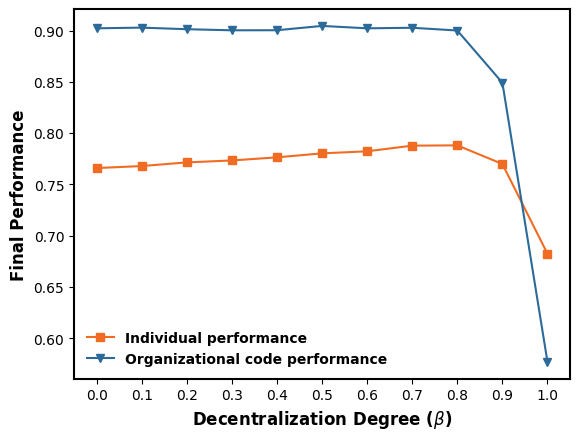

performance list:  [0.76589537 0.76781867 0.77141473 0.77328914 0.77631765 0.78021403
 0.78221943 0.78773346 0.78801257 0.76984216 0.68232356]


<Figure size 640x480 with 0 Axes>

In [7]:
# Impact of beta on final performance
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(beta_array, final_value(hybrid_performance), "-s", color=nature_orange,
        label="Individual performance")
ax.plot(beta_array, final_value(hybrid_code_performance), "-v", color=nature_blue,
        label="Organizational code performance")

plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
plt.ylabel('Final Performance', fontweight='bold', fontsize=12)
plt.xticks(beta_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_final_performance.png")
plt.show()
plt.clf()
print("performance list: ", final_value(hybrid_performance))

In [ ]:
# Impact of beta on late-stage average performance
# This plot is less sensitive to final-period random fluctuation than the final-value plot.
window = 50
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(beta_array, window_average(hybrid_performance, window=window), "-s",
        color=nature_orange, label="Individual performance")
ax.plot(beta_array, window_average(hybrid_code_performance, window=window), "-v",
        color=nature_blue, label="Organizational code performance")

plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
plt.ylabel('Late-stage Average Performance', fontweight='bold', fontsize=12)
plt.xticks(beta_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_late_stage_performance.png")
plt.show()
plt.clf()

In [ ]:
# Impact of beta on diversity
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(beta_array, final_value(hybrid_diversity), "-s", color=nature_green,
        label="Diversity")

plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
plt.ylabel('Final Diversity', fontweight='bold', fontsize=12)
plt.xticks(beta_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_final_diversity.png")
plt.show()
plt.clf()

In [ ]:
# Impact of beta on variance
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(beta_array, final_value(hybrid_variance), "-s", color=nature_blue,
        label="Std. Dev. of individual knowledge levels")

plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
plt.ylabel('Final Std. Dev. of Individual Knowledge Levels', fontweight='bold', fontsize=9)
plt.xticks(beta_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_final_sd.png")
plt.show()
plt.clf()

In [ ]:
# Impact of beta on coefficient of variation
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(beta_array, final_value(hybrid_cv), "-s", color=nature_orange,
        label="Coefficient of variation")

plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
plt.ylabel('Final Coefficient of Variation', fontweight='bold', fontsize=12)
plt.xticks(beta_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_final_cv.png")
plt.show()
plt.clf()

In [ ]:
# Time trajectories by selected beta values
selected_beta_values = [0.0, 0.3, 0.5, 0.7, 1.0]
selected_indices = [int(np.argmin(np.abs(beta_array - beta))) for beta in selected_beta_values]
x = range(hybrid_performance.shape[1])
marker_positions = np.linspace(0, len(x) - 1, num=6, dtype=int)

fig, ax = plt.subplots()
set_axis_style(ax)

markers = ["s", "v", "o", "^", "D"]
for idx, marker in zip(selected_indices, markers):
    ax.plot(x, hybrid_performance[idx], "-" + marker,
            label=rf"$\beta$={beta_array[idx]:.1f}",
            markevery=marker_positions)

plt.xlabel('Time', fontweight='bold', fontsize=12)
plt.ylabel('Performance', fontweight='bold', fontsize=12)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_performance_trajectories.png")
plt.show()
plt.clf()

In [ ]:
# Twin plot: final performance and diversity across beta
fig, ax1 = plt.subplots()
ax1.set_xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Final Performance', fontweight='bold', color="black", fontsize=12)

ax2 = ax1.twinx()
ax2.set_ylabel('Final Diversity', fontweight='bold', color="black", fontsize=12)

ax2.spines['left'].set_color(nature_orange)
ax1.yaxis.label.set_color(nature_orange)
ax1.tick_params(axis='y', colors=nature_orange)
ax2.spines['right'].set_color(nature_blue)
ax2.yaxis.label.set_color(nature_blue)
ax2.tick_params(axis='y', colors=nature_blue)

set_axis_style(ax1)
set_axis_style(ax2)

line_1 = ax1.plot(beta_array, final_value(hybrid_performance), "-s",
                  label="Performance", color=nature_orange)
line_2 = ax2.plot(beta_array, final_value(hybrid_diversity), "--v",
                  label="Diversity", color=nature_blue)

plt.xticks(beta_array)
lines = line_1 + line_2
labs = [line.get_label() for line in lines]
ax1.legend(lines, labs, frameon=False, fontsize=12, loc=(0, 1.02),
           ncol=2, prop=legend_properties)

savefig("hybrid_beta_performance_diversity.png")
plt.show()
plt.clf()

In [ ]:
# Diagnostic: realized share of consensus-channel periods by beta
# This verifies that beta is implemented as the probability of decentralized consensus.
if hybrid_mode is not None:
    consensus_share = []
    for beta_modes in hybrid_mode:
        flat_modes = [mode for run in beta_modes for mode in run]
        consensus_share.append(np.mean([mode == "consensus" for mode in flat_modes]))

    fig, ax = plt.subplots()
    set_axis_style(ax)
    ax.plot(beta_array, consensus_share, "-s", color=nature_green,
            label="Realized consensus share")
    ax.plot(beta_array, beta_array, "k--", label="45-degree reference")

    plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
    plt.ylabel('Realized Share of Consensus Periods', fontweight='bold', fontsize=12)
    plt.xticks(beta_array)
    ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
    savefig("hybrid_beta_realized_consensus_share.png")
    plt.show()
    plt.clf()
else:
    print("hybrid_mode file is unavailable; skip mode diagnostic plot.")

In [ ]:
# Summary table: final values by beta
summary = {
    "beta": beta_array,
    "final_performance": final_value(hybrid_performance),
    "late_stage_performance": window_average(hybrid_performance, window=50),
    "final_code_performance": final_value(hybrid_code_performance),
    "final_diversity": final_value(hybrid_diversity),
    "final_variance": final_value(hybrid_variance),
    "final_cv": final_value(hybrid_cv),
}

for key, value in summary.items():
    print(key, np.round(value, 4))